# GAD-NR: Enron Paper-Faithful Replication

## Enron Dataset Ablation and Paper Comparison

Runs the GAD-NR Enron ablations using the fixed hyperparameter setting reported in the paper: GCN encoder, hidden dimension 16, and decoder loss weights `(feature=0.8, degree=0.5, neighbor=0.001)`. Kaggle and local Mac both default to one seed for a faster 12-run experiment.


## 0. Install Dependencies (Kaggle or Local Mac)

In [1]:
import os
import platform
import subprocess
import sys

IS_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE'))
IS_APPLE_SILICON = platform.system() == 'Darwin' and platform.machine() == 'arm64'
INSTALL_DEPS = IS_KAGGLE  # Kaggle usually lacks torch_geometric; install it automatically there.

if INSTALL_DEPS:
    if IS_KAGGLE:
        # Kaggle GPU path: install PyG sparse extensions from the torch/CUDA wheel index.
        import torch
        torch_ver = torch.__version__.split('+')[0]
        cuda_ver = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
        pyg_url = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_ver}.html'
        print(f'Installing Kaggle PyG wheels for torch={torch_ver}, {cuda_ver}')
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        'torch-scatter', 'torch-sparse', 'torch-cluster', 'torch-spline-conv',
                        '-f', pyg_url, '-q'], check=True)
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        'torch-geometric', 'pygod==0.3.1', 'bioinfokit', '-q'], check=True)
        try:
            import dgl  # noqa: F401
        except ImportError:
            subprocess.run([sys.executable, '-m', 'pip', 'install', 'dgl', '-q'], check=True)
    else:
        # Local Mac path: avoid CUDA-specific wheels and skip DGL, which this notebook does not need. Prefer a fresh conda/venv on Apple Silicon.
        print('Installing local Mac dependencies. This may take a few minutes.')
        subprocess.run([sys.executable, '-m', 'pip', 'install',
                        'torch', 'torch-geometric', 'pygod', 'bioinfokit', '-q'], check=True)
else:
    print('Skipping dependency install. Set INSTALL_DEPS=True if imports fail.')

print(f'Environment: kaggle={IS_KAGGLE}, apple_silicon={IS_APPLE_SILICON}, python={platform.python_version()}')


Installing Kaggle PyG wheels for torch=2.10.0, cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 78.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 100.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 55.5 MB/s eta 0:00:00
Environment: kaggle=True, apple_silicon=False, python=3.12.12


## 1. Imports

In [2]:
import os
import shutil
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import statistics
import scipy
import scipy.optimize
import seaborn as sb
from tqdm import tqdm
from scipy.linalg import sqrtm
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score
import sklearn as sk
import networkx as nx
from torch.autograd import Variable
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GINConv, SAGEConv, GATConv, PNAConv, GraphSAGE
from torch_geometric.utils import add_self_loops
from torch_geometric.transforms import normalize_features
from pygod.utils import load_data
from pygod.utils.utility import check_parameter
try:
    from pygod.metrics import eval_roc_auc
except Exception:
    def eval_roc_auc(label, score):
        return roc_auc_score(label, score)
try:
    from pygod.generator import gen_contextual_outliers, gen_structural_outliers
except ImportError:
    # PyGOD >= 1.x renamed these helpers to singular forms and changed seed kwarg.
    from pygod.generator import gen_contextual_outlier as _gen_contextual_outlier
    from pygod.generator import gen_structural_outlier as _gen_structural_outlier

    def gen_contextual_outliers(data, n, k, random_state=None):
        return _gen_contextual_outlier(data=data, n=n, k=k, seed=random_state)

    def gen_structural_outliers(data, m, n, p=0, random_state=None):
        return _gen_structural_outlier(data=data, m=m, n=n, p=p, seed=random_state)

# DGL is optional here. The official notebooks import it, but this self-contained PyG run does not use it.
try:
    import dgl
    from dgl.data import CitationGraphDataset
except Exception:
    pass

# PyTorch >= 2.6 requires explicitly allowing PyG storage deserialization for some saved datasets.
try:
    from torch_geometric.data.storage import GlobalStorage
    torch.serialization.add_safe_globals([GlobalStorage])
except Exception:
    pass

print('Libraries loaded successfully.')


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
Libraries loaded successfully.


DGL backend not selected or invalid.  Assuming PyTorch for now.


## 2. Configuration

Enron replication setup. The paper fixes GAD-NR to a GCN encoder with hidden dimension 16 and decoder loss weights `(feature=0.8, degree=0.5, neighbor=0.001)` for all non-Cora datasets. Table 2 uses Enron's real benchmark labels; Table 3 injects contextual and structural+joint anomalies using the paper/BOND settings `(contextual n=3, k=25; structural/joint n=3, m=25)`.

Kaggle and local Mac both default to one seed for a faster 12-run experiment. To reproduce the paper-style five-run mean/std exactly, change `SEEDS` to `list(range(5))`.


In [3]:
RUN_LOCALLY = not bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE'))
FORCE_CPU = RUN_LOCALLY  # Recommended on M-series Macs; PyG ops are more reliable on CPU than MPS.
FORCE_PAPER_FIVE_SEEDS_LOCALLY = False

if FORCE_CPU:
    device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device} | run_locally={RUN_LOCALLY} | force_cpu={FORCE_CPU}')

SMOKE_TEST = False  # Set True for a 2-epoch dependency/runtime check.
RUN_TABLE2_ONLY = False  # Run benchmark plus the injected Table 3-style tasks.
SEEDS = [0]  # One-run experiment on both Kaggle and local Mac. Use list(range(5)) for paper-style five-seed replication.


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Dataset
dataset_str = 'enron'
DATA_CACHE_DIR = Path.cwd() / 'pygod_data'

# Paper fixed training setup
lr           = 0.01
epoch_num    = 2 if SMOKE_TEST else 500
loss_step    = 5000  # no scheduled weight change within 500 epochs; preserves fixed paper lambdas
real_loss    = False

# Paper fixed decoder loss weights: lambda_n, lambda_x, lambda_d
base_lambda_loss1 = 0.001  # neighbor reconstruction loss weight (lambda_n)
base_lambda_loss2 = 0.8    # feature reconstruction loss weight (lambda_x)
base_lambda_loss3 = 0.5    # degree reconstruction loss weight (lambda_d)

# Official implementation score-combination weights. The paper publishes the fixed decoder
# weights but not exact score-prime weights, so these repo defaults are documented here.
h_loss_weight       = 1.0
feature_loss_weight = 2.0
degree_loss_weight  = 1.0

# Model architecture
encoder     = 'GCN'
hidden_dim  = 16
sample_size = 10
neigh_loss  = 'KL'

# Dataset preprocessing and anomaly injection parameters from paper Table 6 for Enron
normalize_feat = False
contextual_n = 3
contextual_k = 25
structural_n = 3
structural_m = 25

EXPERIMENTS = [
    {
        'Model': 'GAD-NR (w/o feat. recon.)',
        'lambda_loss1': base_lambda_loss1,
        'lambda_loss2': 0.0,
        'lambda_loss3': base_lambda_loss3,
    },
    {
        'Model': 'GAD-NR (w/o degree recon.)',
        'lambda_loss1': base_lambda_loss1,
        'lambda_loss2': base_lambda_loss2,
        'lambda_loss3': 0.0,
    },
    {
        'Model': 'GAD-NR (w/o neighbor recon.)',
        'lambda_loss1': 0.0,
        'lambda_loss2': base_lambda_loss2,
        'lambda_loss3': base_lambda_loss3,
    },
    {
        'Model': 'GAD-NR',
        'lambda_loss1': base_lambda_loss1,
        'lambda_loss2': base_lambda_loss2,
        'lambda_loss3': base_lambda_loss3,
    },
]

TASKS = [
    {'Task': 'Benchmark', 'paper_table': 'Table 2'},
    {'Task': 'Contextual', 'paper_table': 'Table 3 contextual'},
    {'Task': 'Structural+Joint', 'paper_table': 'Table 3 structural+joint'},
]
ACTIVE_TASKS = TASKS[:1] if RUN_TABLE2_ONLY else TASKS

PAPER_REFERENCES = {
    ('Benchmark', 'GAD-NR (w/o feat. recon.)'): (70.20, 1.16),
    ('Benchmark', 'GAD-NR (w/o degree recon.)'): (72.44, 1.33),
    ('Benchmark', 'GAD-NR (w/o neighbor recon.)'): (56.01, 3.00),
    ('Benchmark', 'GAD-NR'): (80.87, 2.95),
    ('Contextual', 'GAD-NR (w/o feat. recon.)'): (68.27, 2.09),
    ('Contextual', 'GAD-NR (w/o degree recon.)'): (75.25, 3.57),
    ('Contextual', 'GAD-NR (w/o neighbor recon.)'): (68.23, 3.34),
    ('Contextual', 'GAD-NR'): (85.79, 2.65),
    ('Structural+Joint', 'GAD-NR (w/o feat. recon.)'): (79.18, 2.01),
    ('Structural+Joint', 'GAD-NR (w/o degree recon.)'): (72.19, 0.06),
    ('Structural+Joint', 'GAD-NR (w/o neighbor recon.)'): (75.65, 1.39),
    ('Structural+Joint', 'GAD-NR'): (82.22, 2.14),
}

print('Configuration:')
print(f'  dataset={dataset_str}, encoder={encoder}, hidden_dim={hidden_dim}')
print(f'  lr={lr}, epochs={epoch_num}, sample_size={sample_size}, seeds={SEEDS}')
print(f'  base lambda_n={base_lambda_loss1}, lambda_x={base_lambda_loss2}, lambda_d={base_lambda_loss3}')
print(f'  tasks={len(ACTIVE_TASKS)}/{len(TASKS)}, variants={len(EXPERIMENTS)}, smoke_test={SMOKE_TEST}, table2_only={RUN_TABLE2_ONLY}')


Using device: cuda | run_locally=False | force_cpu=False
Configuration:
  dataset=enron, encoder=GCN, hidden_dim=16
  lr=0.01, epochs=500, sample_size=10, seeds=[0]
  base lambda_n=0.001, lambda_x=0.8, lambda_d=0.5
  tasks=3/3, variants=4, smoke_test=False, table2_only=False


## 3. Utility Functions

In [4]:
def _normalize(x):
    x_min = x.min()
    x_max = x.max()
    x_norm = (x - x_min) / x_max
    return x_norm


def gen_joint_structural_outliers(data, m, n, random_state=None):
    """
    Randomly select n nodes as anomalies and connect each to m other random nodes.
    """
    if not isinstance(data, Data):
        raise TypeError('data should be torch_geometric.data.Data')
    if isinstance(m, int):
        check_parameter(m, low=0, high=data.num_nodes, param_name='m')
    else:
        raise ValueError('m should be int, got %s' % m)
    if isinstance(n, int):
        check_parameter(n, low=0, high=data.num_nodes, param_name='n')
    else:
        raise ValueError('n should be int, got %s' % n)
    check_parameter(m * n, low=0, high=data.num_nodes, param_name='m*n')

    if random_state is not None:
        np.random.seed(random_state)

    outlier_idx = np.random.choice(data.num_nodes, size=n, replace=False)
    new_edges = []
    for outlier_node in outlier_idx:
        other_idx = np.random.choice(data.num_nodes, size=m, replace=False)
        for j in other_idx:
            new_edges.append(torch.tensor([[outlier_node, j]], dtype=torch.long))

    new_edges = torch.cat(new_edges)
    y_outlier = torch.zeros(data.x.shape[0], dtype=torch.long)
    y_outlier[outlier_idx] = 1
    data.edge_index = torch.cat([data.edge_index, new_edges.T], dim=1)
    return data, y_outlier


def KL_neighbor_loss(predictions, targets, mask_len):
    x1 = predictions.squeeze().cpu().detach().float()
    x2 = targets.squeeze().cpu().detach().float()
    mean_x1 = x1.mean(0)
    mean_x2 = x2.mean(0)
    nn = x1.shape[0]
    h_dim = x1.shape[1]
    cov_x1 = (x1 - mean_x1).transpose(1, 0).matmul(x1 - mean_x1) / max((nn - 1), 1)
    cov_x2 = (x2 - mean_x2).transpose(1, 0).matmul(x2 - mean_x2) / max((nn - 1), 1)

    # The paper/code use Gaussian KL for neighbor reconstruction. On small sampled
    # neighborhoods, covariance determinants can become numerically unstable; slogdet
    # plus a small jitter keeps the same objective finite for ROC-AUC evaluation.
    eye = torch.eye(h_dim, dtype=cov_x1.dtype, device=cov_x1.device)
    cov_x1 = cov_x1 + eye + 1e-6 * eye
    cov_x2 = cov_x2 + eye + 1e-6 * eye
    sign1, logdet1 = torch.linalg.slogdet(cov_x1)
    sign2, logdet2 = torch.linalg.slogdet(cov_x2)
    if sign1 <= 0 or sign2 <= 0:
        cov_x1 = cov_x1 + 1e-3 * eye
        cov_x2 = cov_x2 + 1e-3 * eye
        sign1, logdet1 = torch.linalg.slogdet(cov_x1)
        sign2, logdet2 = torch.linalg.slogdet(cov_x2)

    cov_x2_inv = torch.linalg.pinv(cov_x2)
    mean_diff = (mean_x2 - mean_x1).reshape(1, -1)
    KL_loss = 0.5 * ((logdet1 - logdet2) - h_dim
                     + torch.trace(cov_x2_inv.matmul(cov_x1))
                     + mean_diff.matmul(cov_x2_inv).matmul(mean_diff.T).squeeze())
    KL_loss = torch.nan_to_num(KL_loss, nan=0.0, posinf=1e6, neginf=0.0).to(device)
    return KL_loss


def W2_neighbor_loss(predictions, targets, mask_len):
    x1 = predictions.squeeze().cpu().detach()
    x2 = targets.squeeze().cpu().detach()
    mean_x1 = x1.mean(0)
    mean_x2 = x2.mean(0)
    nn = x1.shape[0]
    cov_x1 = (x1 - mean_x1).transpose(1, 0).matmul(x1 - mean_x1) / (nn - 1)
    cov_x2 = (x2 - mean_x2).transpose(1, 0).matmul(x2 - mean_x2) / (nn - 1)
    W2_loss = (torch.square(mean_x1 - mean_x2).sum()
               + torch.trace(cov_x1 + cov_x2
                             + 2 * sqrtm(sqrtm(cov_x1) @ (cov_x2.numpy()) @ (sqrtm(cov_x1)))))
    return W2_loss


print('Utility functions defined.')

Utility functions defined.


## 4. Model Layers

In [5]:
class MLP(nn.Module):
    def __init__(self, num_layers, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.linear_or_not = True
        self.num_layers = num_layers
        if num_layers < 1:
            raise ValueError('number of layers should be positive!')
        elif num_layers == 1:
            self.linear = nn.Linear(input_dim, output_dim)
        else:
            self.linear_or_not = False
            self.linears = torch.nn.ModuleList()
            self.batch_norms = torch.nn.ModuleList()
            self.linears.append(nn.Linear(input_dim, hidden_dim))
            for layer in range(num_layers - 2):
                self.linears.append(nn.Linear(hidden_dim, hidden_dim))
            self.linears.append(nn.Linear(hidden_dim, output_dim))
            for layer in range(num_layers - 1):
                self.batch_norms.append(nn.BatchNorm1d((hidden_dim)))

    def forward(self, x):
        if self.linear_or_not:
            return self.linear(x)
        else:
            h = x
            for layer in range(self.num_layers - 1):
                h = self.linears[layer](h)
                if len(h.shape) > 2:
                    h = torch.transpose(h, 0, 1)
                    h = torch.transpose(h, 1, 2)
                h = self.batch_norms[layer](h)
                if len(h.shape) > 2:
                    h = torch.transpose(h, 1, 2)
                    h = torch.transpose(h, 0, 1)
                h = F.relu(h)
            return self.linears[self.num_layers - 1](h)


class MLP_generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP_generator, self).__init__()
        self.linear  = nn.Linear(input_dim, output_dim)
        self.linear2 = nn.Linear(output_dim, output_dim)
        self.linear3 = nn.Linear(output_dim, output_dim)
        self.linear4 = nn.Linear(output_dim, output_dim)

    def forward(self, embedding):
        neighbor_embedding = F.relu(self.linear(embedding))
        neighbor_embedding = F.relu(self.linear2(neighbor_embedding))
        neighbor_embedding = F.relu(self.linear3(neighbor_embedding))
        neighbor_embedding = self.linear4(neighbor_embedding)
        return neighbor_embedding


class PairNorm(nn.Module):
    def __init__(self, mode='PN', scale=10):
        assert mode in ['None', 'PN', 'PN-SI', 'PN-SCS']
        super(PairNorm, self).__init__()
        self.mode = mode
        self.scale = scale

    def forward(self, x):
        if self.mode == 'None':
            return x
        col_mean = x.mean(dim=0)
        if self.mode == 'PN':
            x = x - col_mean
            rownorm_mean = (1e-6 + x.pow(2).sum(dim=1).mean()).sqrt()
            x = self.scale * x / rownorm_mean
        if self.mode == 'PN-SI':
            x = x - col_mean
            rownorm_individual = (1e-6 + x.pow(2).sum(dim=1, keepdim=True)).sqrt()
            x = self.scale * x / rownorm_individual
        if self.mode == 'PN-SCS':
            rownorm_individual = (1e-6 + x.pow(2).sum(dim=1, keepdim=True)).sqrt()
            x = self.scale * x / rownorm_individual - col_mean
        return x


class FNN(nn.Module):
    def __init__(self, in_features, hidden, out_features, layer_num):
        super(FNN, self).__init__()
        self.linear1 = MLP(layer_num, in_features, hidden, out_features)
        self.linear2 = nn.Linear(out_features, out_features)

    def forward(self, embedding):
        x = self.linear1(embedding)
        x = self.linear2(F.relu(x))
        x = F.relu(x)
        return x


print('Model layers defined.')

Model layers defined.


## 5. GAD-NR Model (GNNStructEncoder)

In [6]:
def generate_gt_neighbor(neighbor_dict, node_embeddings, neighbor_num_list, in_dim):
    max_neighbor_num = max(neighbor_num_list)
    all_gt_neighbor_embeddings = []
    for i, embedding in enumerate(node_embeddings):
        neighbor_indexes = neighbor_dict[i]
        neighbor_embeddings = []
        for index in neighbor_indexes:
            neighbor_embeddings.append(node_embeddings[index].tolist())
        if len(neighbor_embeddings) < max_neighbor_num:
            for _ in range(max_neighbor_num - len(neighbor_embeddings)):
                neighbor_embeddings.append(torch.zeros(in_dim).tolist())
        all_gt_neighbor_embeddings.append(neighbor_embeddings)
    return all_gt_neighbor_embeddings


class GNNStructEncoder(nn.Module):
    def __init__(self, in_dim0, in_dim, hidden_dim, layer_num, sample_size, device, neighbor_num_list,
                 GNN_name='GIN', norm_mode='PN-SCS', norm_scale=20,
                 lambda_loss1=0.01, lambda_loss2=0.001, lambda_loss3=0.0001):
        super(GNNStructEncoder, self).__init__()

        self.mlp0 = nn.Linear(in_dim0, hidden_dim)
        self.norm = PairNorm(norm_mode, norm_scale)
        self.out_dim = hidden_dim
        self.lambda_loss1 = lambda_loss1
        self.lambda_loss2 = lambda_loss2
        self.lambda_loss3 = lambda_loss3

        if GNN_name == 'GIN':
            self.linear1 = MLP(layer_num, hidden_dim, hidden_dim, hidden_dim)
            self.graphconv1 = GINConv(self.linear1)
            self.linear2 = MLP(layer_num, hidden_dim, hidden_dim, hidden_dim)
            self.graphconv2 = GINConv(self.linear2)
        elif GNN_name == 'GCN':
            self.graphconv1 = GCNConv(hidden_dim, hidden_dim)
            self.graphconv2 = GCNConv(hidden_dim, hidden_dim)
        elif GNN_name == 'GAT':
            self.graphconv1 = GATConv(hidden_dim, hidden_dim)
            self.graphconv2 = GATConv(hidden_dim, hidden_dim)
        else:  # SAGE branch retained for optional diagnostics
            self.graphconv1 = SAGEConv(hidden_dim, hidden_dim, aggr='sum')

        self.neighbor_num_list = neighbor_num_list
        self.tot_node = len(neighbor_num_list)

        self.gaussian_mean = nn.Parameter(
            torch.FloatTensor(sample_size, hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.gaussian_log_sigma = nn.Parameter(
            torch.FloatTensor(sample_size, hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.m = torch.distributions.Normal(torch.zeros(sample_size, hidden_dim),
                                            torch.ones(sample_size, hidden_dim))
        self.m_batched = torch.distributions.Normal(
            torch.zeros(sample_size, self.tot_node, hidden_dim),
            torch.ones(sample_size, self.tot_node, hidden_dim))
        self.m_h = torch.distributions.Normal(torch.zeros(sample_size, hidden_dim),
                                              50 * torch.ones(sample_size, hidden_dim))

        self.mlp_gaussian_mean = nn.Parameter(
            torch.FloatTensor(hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.mlp_gaussian_log_sigma = nn.Parameter(
            torch.FloatTensor(hidden_dim).uniform_(-0.5 / hidden_dim, 0.5 / hidden_dim)).to(device)
        self.mlp_m = torch.distributions.Normal(torch.zeros(hidden_dim), torch.ones(hidden_dim))

        self.mlp_mean  = FNN(hidden_dim, hidden_dim, hidden_dim, 3)
        self.mlp_sigma = FNN(hidden_dim, hidden_dim, hidden_dim, 3)
        self.softplus  = nn.Softplus()

        self.mean_agg = SAGEConv(hidden_dim, hidden_dim, aggr='mean', normalize=False)
        self.std_agg  = PNAConv(hidden_dim, hidden_dim, aggregators=['std'],
                                scalers=['identity'], deg=neighbor_num_list)
        self.layer1_generator = MLP_generator(hidden_dim, hidden_dim)

        self.degree_decoder  = FNN(hidden_dim, hidden_dim, 1, 4)
        self.feature_decoder = FNN(hidden_dim, hidden_dim, in_dim, 3)
        self.degree_loss_func  = nn.MSELoss()
        self.feature_loss_func = nn.MSELoss()
        # Multiprocessing pools are unused in this notebook path; keeping this off
        # avoids process leaks across the 60-run Kaggle replication.
        self.pool = None
        self.in_dim  = in_dim
        self.sample_size = sample_size
        self.init_projection = FNN(in_dim, hidden_dim, hidden_dim, 1)

    def forward_encoder(self, x, edge_index):
        h0 = self.mlp0(x)
        l1 = self.graphconv1(h0, edge_index)
        return l1, h0

    def sample_neighbors(self, indexes, neighbor_dict, gt_embeddings):
        sampled_embeddings_list = []
        mark_len_list = []
        for index in indexes:
            sampled_embeddings = []
            neighbor_indexes = neighbor_dict[index]
            if len(neighbor_indexes) < self.sample_size:
                mask_len = len(neighbor_indexes)
                sample_indexes = neighbor_indexes
            else:
                sample_indexes = random.sample(neighbor_indexes, self.sample_size)
                mask_len = self.sample_size
            for index in sample_indexes:
                sampled_embeddings.append(gt_embeddings[index].tolist())
            if len(sampled_embeddings) < self.sample_size:
                for _ in range(self.sample_size - len(sampled_embeddings)):
                    sampled_embeddings.append(torch.zeros(self.out_dim).tolist())
            sampled_embeddings_list.append(sampled_embeddings)
            mark_len_list.append(mask_len)
        return sampled_embeddings_list, mark_len_list

    def reconstruction_neighbors2(self, l1, h0, edge_index):
        mean_neigh = self.mean_agg(h0, edge_index).detach()
        std_neigh  = self.std_agg(h0, edge_index).detach()
        cov_neigh  = torch.bmm(std_neigh.unsqueeze(dim=-1), std_neigh.unsqueeze(dim=1))
        target_mean = mean_neigh
        target_cov  = cov_neigh

        self_embedding = l1.unsqueeze(0).repeat(self.sample_size, 1, 1)
        generated_mean  = self.mlp_mean(self_embedding)
        generated_sigma = self.mlp_sigma(self_embedding)
        std_z = self.m_batched.sample().to(device)
        var  = generated_mean + generated_sigma.exp() * std_z
        nhij = self.layer1_generator(var)

        generated_mean = torch.mean(nhij, dim=0)
        generated_std  = torch.std(nhij, dim=0)
        generated_cov  = torch.bmm(generated_std.unsqueeze(dim=-1),
                                   generated_std.unsqueeze(dim=1)) / self.sample_size

        tot_nodes = l1.shape[0]
        h_dim = l1.shape[1]
        batch_eye = torch.eye(h_dim).to(device).unsqueeze(0).repeat(tot_nodes, 1, 1)

        target_cov    = target_cov + batch_eye
        generated_cov = generated_cov + batch_eye

        det_target_cov    = torch.linalg.det(target_cov)
        det_generated_cov = torch.linalg.det(generated_cov)
        trace_mat = torch.matmul(torch.inverse(generated_cov), target_cov)

        x = torch.bmm(torch.unsqueeze(generated_mean - target_mean, dim=1),
                      torch.inverse(generated_cov))
        y = torch.unsqueeze(generated_mean - target_mean, dim=-1)
        z = torch.bmm(x, y).squeeze()

        KL_loss = 0.5 * (torch.log(det_target_cov / det_generated_cov) - h_dim
                         + trace_mat.diagonal(offset=0, dim1=-1, dim2=-2).sum(-1) + z)
        return torch.mean(KL_loss), KL_loss

    def reconstruction_neighbors(self, FNN_generator, neighbor_indexes, neighbor_dict,
                                 from_layer, to_layer, device):
        local_index_loss = 0
        local_index_loss_per_node = []
        sampled_embeddings_list, mark_len_list = self.sample_neighbors(
            neighbor_indexes, neighbor_dict, to_layer)
        for i, neighbor_embeddings1 in enumerate(sampled_embeddings_list):
            index = neighbor_indexes[i]
            mask_len1 = mark_len_list[i]
            mean  = self.mlp_mean(from_layer[index].repeat(self.sample_size, 1))
            sigma = self.mlp_sigma(from_layer[index].repeat(self.sample_size, 1))
            std_z = self.m.sample().to(device)
            var   = mean + sigma.exp() * std_z
            nhij  = FNN_generator(var)
            generated_neighbors = torch.unsqueeze(nhij, dim=0).to(device)
            target_neighbors = torch.unsqueeze(
                torch.FloatTensor(neighbor_embeddings1), dim=0).to(device)
            if neigh_loss == 'KL':
                loss_val = KL_neighbor_loss(generated_neighbors, target_neighbors, mask_len1)
            else:
                loss_val = W2_neighbor_loss(generated_neighbors, target_neighbors, mask_len1)
            local_index_loss += loss_val
            local_index_loss_per_node.append(loss_val)
        local_index_loss_per_node = torch.stack(local_index_loss_per_node)
        return local_index_loss, local_index_loss_per_node

    def neighbor_decoder(self, gij, ground_truth_degree_matrix, h0, neighbor_dict,
                         device, h, edge_index):
        tot_nodes = gij.shape[0]
        degree_logits = self.degree_decoding(gij)
        ground_truth_degree_matrix = torch.unsqueeze(ground_truth_degree_matrix, dim=1)
        degree_loss = self.degree_loss_func(degree_logits, ground_truth_degree_matrix.float())
        degree_loss_per_node = (degree_logits - ground_truth_degree_matrix).pow(2)

        h_loss = 0
        feature_loss = 0
        loss_list = []
        loss_list_per_node = []
        feature_loss_list = []

        for _ in range(3):
            h0_prime = self.feature_decoder(gij)
            feature_losses_per_node = (h0 - h0_prime).pow(2).mean(1)
            feature_loss_list.append(feature_losses_per_node)
            local_index_loss, local_index_loss_per_node = self.reconstruction_neighbors2(
                gij, h0, edge_index)
            loss_list.append(local_index_loss)
            loss_list_per_node.append(local_index_loss_per_node)

        loss_list = torch.stack(loss_list)
        h_loss += torch.mean(loss_list)
        loss_list_per_node = torch.stack(loss_list_per_node)
        h_loss_per_node = torch.mean(loss_list_per_node, dim=0)

        feature_loss_per_node = torch.mean(torch.stack(feature_loss_list), dim=0)
        feature_loss += torch.mean(torch.stack(feature_loss_list))

        h_loss_per_node      = h_loss_per_node.reshape(tot_nodes, 1)
        degree_loss_per_node = degree_loss_per_node.reshape(tot_nodes, 1)
        feature_loss_per_node = feature_loss_per_node.reshape(tot_nodes, 1)

        loss = (self.lambda_loss1 * h_loss
                + degree_loss * self.lambda_loss3
                + self.lambda_loss2 * feature_loss)
        loss_per_node = (self.lambda_loss1 * h_loss_per_node
                         + degree_loss_per_node * self.lambda_loss3
                         + self.lambda_loss2 * feature_loss_per_node)
        return loss, loss_per_node, h_loss_per_node, degree_loss_per_node, feature_loss_per_node

    def degree_decoding(self, node_embeddings):
        return F.relu(self.degree_decoder(node_embeddings))

    def forward(self, edge_index, x, ground_truth_degree_matrix, neighbor_dict, device):
        l1, h0 = self.forward_encoder(x, edge_index)
        loss, loss_per_node, h_loss, degree_loss, feature_loss = self.neighbor_decoder(
            l1, ground_truth_degree_matrix, h0, neighbor_dict, device, x, edge_index)
        return loss, loss_per_node, h_loss, degree_loss, feature_loss


print('GNNStructEncoder defined.')

GNNStructEncoder defined.


## 6. Training and Evaluation Functions

In [7]:
def sanitize_score_tensor(values, name):
    values = values.reshape(-1).clone().float()
    finite_mask = torch.isfinite(values)
    if finite_mask.all():
        return values

    finite_values = values[finite_mask]
    if finite_values.numel() == 0:
        print(f'Warning: {name} contained no finite values; replacing with zeros.')
        return torch.zeros_like(values)

    high = finite_values.max().item()
    low = finite_values.min().item()
    print(f'Warning: {name} contained non-finite values; replacing NaN/+inf with {high:.6g} and -inf with {low:.6g}.')
    return torch.nan_to_num(values, nan=high, posinf=high, neginf=low)


def original_gadnr_score_scale(values, name):
    values = sanitize_score_tensor(values, name)
    value_range = torch.max(values) - torch.min(values)
    if value_range <= 1e-12:
        return torch.zeros_like(values)
    # Match the official GAD-NR notebooks: divide by range only. Do not subtract min,
    # because that changes the summed anomaly-score ranking and therefore ROC-AUC.
    return values / value_range


def candidate_data_dirs():
    dirs = []
    cwd = Path.cwd()
    for base in [cwd, *cwd.parents]:
        dirs.append(base / 'pygod_data')
    if IS_KAGGLE:
        dirs.append(Path('/kaggle/working/pygod_data'))
    # Preserve order while removing duplicates.
    seen = set()
    unique_dirs = []
    for path in dirs:
        if path not in seen:
            seen.add(path)
            unique_dirs.append(path)
    return unique_dirs


def load_enron_data_local_first():
    for data_dir in candidate_data_dirs():
        file_path = data_dir / f'{dataset_str}.pt'
        zip_path = data_dir / f'{dataset_str}.pt.zip'
        if file_path.exists():
            try:
                return torch.load(file_path, weights_only=False)
            except TypeError:
                return torch.load(file_path)
        if zip_path.exists():
            data_dir.mkdir(parents=True, exist_ok=True)
            shutil.unpack_archive(str(zip_path), str(data_dir))
            try:
                return torch.load(file_path, weights_only=False)
            except TypeError:
                return torch.load(file_path)

    DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    try:
        return load_data(dataset_str, cache_dir=str(DATA_CACHE_DIR))
    except TypeError:
        try:
            return load_data(dataset_str)
        except Exception as exc:
            raise RuntimeError(
                'Could not load the Enron dataset locally. Connect to the internet and rerun, '
                'or manually download https://github.com/pygod-team/data/raw/main/enron.pt.zip, '
                f'unzip it, and place enron.pt in one of: {candidate_data_dirs()}.'
            ) from exc
    except Exception as exc:
        raise RuntimeError(
            'Could not load the Enron dataset locally. Connect to the internet and rerun, '
            'or manually download https://github.com/pygod-team/data/raw/main/enron.pt.zip, '
            f'unzip it, and place enron.pt in one of: {candidate_data_dirs()}.'
        ) from exc


def prepare_enron_task(task_name):
    data = load_enron_data_local_first()
    print(f'Loaded {dataset_str} for {task_name}: {data.num_nodes} nodes, '
          f'{data.edge_index.shape[1]} edge entries, '
          f'{data.x.shape[1]} features, '
          f'{int(data.y.sum())} real anomalies')

    if normalize_feat:
        data.x = (data.x - data.x.min()) / data.x.max()

    if task_name == 'Benchmark':
        labels = data.y.bool().cpu().detach()
    elif task_name == 'Contextual':
        data, yc = gen_contextual_outliers(data=data, n=contextual_n, k=contextual_k)
        labels = yc.bool().cpu().detach()
    elif task_name == 'Structural+Joint':
        data, ys = gen_structural_outliers(data=data, n=structural_n, m=structural_m, p=0.2)
        data, yj = gen_joint_structural_outliers(data=data, n=structural_n, m=structural_m)
        labels = torch.logical_or(ys, yj).bool().cpu().detach()
    else:
        raise ValueError(f'Unknown task: {task_name}')

    edge_index = data.edge_index.cpu()
    num_nodes = data.x.shape[0]
    self_edges = torch.tensor([[i for i in range(num_nodes)],
                               [i for i in range(num_nodes)]], dtype=torch.long)
    data.edge_index = torch.cat([edge_index, self_edges], dim=1)
    data = data.to(device)
    return data, labels

def train_one_run(data, labels, lr, epoch, device, encoder,
                  lambda_loss1, lambda_loss2, lambda_loss3, hidden_dim,
                  sample_size=10, loss_step=20, real_loss=False,
                  h_score_weight=1.0, feature_score_weight=2.0, degree_score_weight=1.0):

    in_nodes = data.edge_index[0, :]
    out_nodes = data.edge_index[1, :]

    neighbor_dict = {}
    for in_node, out_node in zip(in_nodes, out_nodes):
        if in_node.item() not in neighbor_dict:
            neighbor_dict[in_node.item()] = []
        neighbor_dict[in_node.item()].append(out_node.item())

    neighbor_num_list = torch.tensor([len(neighbor_dict[i]) for i in neighbor_dict]).to(device)

    in_dim = data.x.shape[1]
    GNNModel = GNNStructEncoder(
        in_dim, hidden_dim, hidden_dim, 2, sample_size, device=device,
        neighbor_num_list=neighbor_num_list, GNN_name=encoder,
        lambda_loss1=lambda_loss1, lambda_loss2=lambda_loss2, lambda_loss3=lambda_loss3)
    GNNModel.to(device)

    degree_params = list(map(id, GNNModel.degree_decoder.parameters()))
    base_params = filter(lambda p: id(p) not in degree_params, GNNModel.parameters())
    opt = torch.optim.Adam(
        [{'params': base_params},
         {'params': GNNModel.degree_decoder.parameters(), 'lr': 1e-2}],
        lr=lr, weight_decay=0.0003)

    min_loss = float('inf')
    best_auc = 0.0
    best_epoch = 0
    loss_values = []
    status = 'completed'

    for i in tqdm(range(1, epoch + 1)):
        if i % loss_step == 0:
            GNNModel.lambda_loss2 = GNNModel.lambda_loss2 + 0.5
            GNNModel.lambda_loss3 = GNNModel.lambda_loss3 / 2

        loss, loss_per_node, h_loss, degree_loss, feature_loss = GNNModel(
            data.edge_index, data.x, neighbor_num_list, neighbor_dict, device=device)
        if not torch.isfinite(loss):
            status = f'stopped_nonfinite_loss_epoch_{i}'
            print(f'Warning: training loss became non-finite at epoch {i}; stopping this run and keeping best AUC so far.')
            break

        loss_per_node = sanitize_score_tensor(loss_per_node.cpu().detach(), 'loss_per_node')
        h_loss = h_loss.cpu().detach()
        degree_loss = degree_loss.cpu().detach()
        feature_loss = feature_loss.cpu().detach()

        h_loss_norm = original_gadnr_score_scale(h_loss, 'h_loss')
        degree_loss_norm = original_gadnr_score_scale(degree_loss, 'degree_loss')
        feature_loss_norm = original_gadnr_score_scale(feature_loss, 'feature_loss')

        combined_score = (h_score_weight * h_loss_norm
                          + degree_score_weight * degree_loss_norm
                          + feature_score_weight * feature_loss_norm)
        anomaly_score = loss_per_node if real_loss else sanitize_score_tensor(combined_score, 'combined_score')

        auc_score = eval_roc_auc(labels.numpy(), anomaly_score.numpy()) * 100
        if auc_score > best_auc:
            best_auc = auc_score
            best_epoch = i

        if i % 50 == 0 or i == 1 or i == epoch:
            print(f'Epoch {i:4d}/{epoch} | Loss: {loss.item():.5f} '
                  f'| AUC: {auc_score:.2f}% | Best AUC: {best_auc:.2f}%')

        if loss < min_loss:
            min_loss = loss.item()

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_values.append(loss.cpu().detach().item())

    return {
        'Best AUC': best_auc,
        'Best Epoch': best_epoch,
        'Min Loss': min_loss,
        'Loss Values': loss_values,
        'Status': status,
    }


def summarize_paper_comparison(run_level_df):
    rows = []
    grouped = run_level_df.groupby(['Task', 'Model'], sort=False)
    for (task, model), group in grouped:
        auc_values = group['Best AUC'].astype(float)
        paper_mean, paper_std = PAPER_REFERENCES[(task, model)]
        mean_auc = auc_values.mean()
        std_auc = auc_values.std(ddof=1) if len(auc_values) > 1 else 0.0
        delta = mean_auc - paper_mean
        rows.append({
            'Task': task,
            'Model': model,
            'Runs': len(auc_values),
            'Mean AUC': round(mean_auc, 2),
            'Std AUC': round(std_auc, 2),
            'Paper Mean': paper_mean,
            'Paper Std': paper_std,
            'Delta Mean': round(delta, 2),
            'Abs Delta': round(abs(delta), 2),
            'Within Paper Std': abs(delta) <= paper_std,
            'Mean Best Epoch': round(group['Best Epoch'].mean(), 1),
            'Mean Min Loss': round(group['Min Loss'].mean(), 6),
        })
    return pd.DataFrame(rows)


print('Training and evaluation functions defined.')


Training and evaluation functions defined.


## 7. Run Paper-Faithful Experiments

Runs the active Enron evaluation tasks with four GAD-NR variants. `RUN_TABLE2_ONLY=False` runs the clean benchmark task plus the injected Table 3-style tasks. On Kaggle this is 60 runs by default; locally it is 12 runs by default.


In [8]:
print('GAD-NR: Paper-Faithful Enron Replication')
print(f'Dataset={dataset_str} | encoder={encoder} | hidden={hidden_dim} | lr={lr}')
print(f'score weights: neigh={h_loss_weight}, feature={feature_loss_weight}, degree={degree_loss_weight}')
print('-' * 90)

run_rows = []
loss_history = {}
total_runs = len(ACTIVE_TASKS) * len(EXPERIMENTS) * len(SEEDS)
run_counter = 0

for task in ACTIVE_TASKS:
    task_name = task['Task']
    for experiment in EXPERIMENTS:
        model_name = experiment['Model']
        for seed in SEEDS:
            run_counter += 1
            set_seed(seed)

            print(f'\n[{run_counter}/{total_runs}] Task={task_name} | Model={model_name} | Seed={seed}')
            print(f"lambda_n={experiment['lambda_loss1']} | "
                  f"lambda_x={experiment['lambda_loss2']} | "
                  f"lambda_d={experiment['lambda_loss3']}")
            print('-' * 90)

            data, labels = prepare_enron_task(task_name)
            result = train_one_run(
                data=data,
                labels=labels,
                lr=lr,
                epoch=epoch_num,
                device=device,
                encoder=encoder,
                lambda_loss1=experiment['lambda_loss1'],
                lambda_loss2=experiment['lambda_loss2'],
                lambda_loss3=experiment['lambda_loss3'],
                hidden_dim=hidden_dim,
                sample_size=sample_size,
                loss_step=loss_step,
                real_loss=real_loss,
                h_score_weight=h_loss_weight,
                feature_score_weight=feature_loss_weight,
                degree_score_weight=degree_loss_weight,
            )

            paper_mean, paper_std = PAPER_REFERENCES[(task_name, model_name)]
            run_rows.append({
                'Task': task_name,
                'Paper Table': task['paper_table'],
                'Model': model_name,
                'Seed': seed,
                'Best AUC': round(result['Best AUC'], 4),
                'Best Epoch': result['Best Epoch'],
                'Min Loss': round(result['Min Loss'], 6),
                'Status': result['Status'],
                'Paper Mean': paper_mean,
                'Paper Std': paper_std,
                'Lambda Neighbor': experiment['lambda_loss1'],
                'Lambda Feature': experiment['lambda_loss2'],
                'Lambda Degree': experiment['lambda_loss3'],
            })
            loss_history[(task_name, model_name, seed)] = result['Loss Values']

run_level_df = pd.DataFrame(run_rows)
summary_df = summarize_paper_comparison(run_level_df)

run_level_df.to_csv('gadnr_enron_paper_run_level_results.csv', index=False)
summary_df.to_csv('gadnr_enron_paper_comparison_summary.csv', index=False)

expected_rows = len(ACTIVE_TASKS) * len(EXPERIMENTS) * len(SEEDS)
assert len(run_level_df) == expected_rows, f'Expected {expected_rows} run rows, got {len(run_level_df)}'
assert len(summary_df) == len(ACTIVE_TASKS) * len(EXPERIMENTS), 'Unexpected summary row count'
assert run_level_df['Best AUC'].between(0, 100).all(), 'AUC values must be between 0 and 100'

print('\n=== Run-Level Results ===')
print(run_level_df.to_string(index=False))
print('\n=== Paper Comparison Summary ===')
print(summary_df.to_string(index=False))
print('\nSaved CSVs:')
print('  gadnr_enron_paper_run_level_results.csv')
print('  gadnr_enron_paper_comparison_summary.csv')


GAD-NR: Paper-Faithful Enron Replication
Dataset=enron | encoder=GCN | hidden=16 | lr=0.01
score weights: neigh=1.0, feature=2.0, degree=1.0
------------------------------------------------------------------------------------------

[1/12] Task=Benchmark | Model=GAD-NR (w/o feat. recon.) | Seed=0
lambda_n=0.001 | lambda_x=0.0 | lambda_d=0.5
------------------------------------------------------------------------------------------
Loaded enron for Benchmark: 13533 nodes, 176987 edge entries, 18 features, 5 real anomalies


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch    1/500 | Loss: 573.73669 | AUC: 76.67% | Best AUC: 76.67%


 10%|█         | 51/500 [00:09<01:03,  7.12it/s]

Epoch   50/500 | Loss: 573.70929 | AUC: 26.55% | Best AUC: 76.67%


...

Epoch  400/500 | Loss: 475.51361 | AUC: 48.22% | Best AUC: 67.10%


 90%|█████████ | 451/500 [01:01<00:06,  7.49it/s]

Epoch  450/500 | Loss: 471.04074 | AUC: 57.19% | Best AUC: 67.10%


100%|██████████| 500/500 [01:07<00:00,  7.36it/s]


Epoch  500/500 | Loss: 465.37567 | AUC: 51.49% | Best AUC: 67.10%

=== Run-Level Results ===
            Task              Paper Table                        Model  Seed  Best AUC  Best Epoch   Min Loss    Status  Paper Mean  Paper Std  Lambda Neighbor  Lambda Feature  Lambda Degree
       Benchmark                  Table 2    GAD-NR (w/o feat. recon.)     0   80.2994         145 518.117737 completed       70.20       1.16            0.001             0.0            0.5
       Benchmark                  Table 2   GAD-NR (w/o degree recon.)     0   76.9182           5   0.000356 completed       72.44       1.33            0.001             0.8            0.0
       Benchmark                  Table 2 GAD-NR (w/o neighbor recon.)     0   77.4941           5 518.117371 completed       56.01       3.00            0.000             0.8            0.5
       Benchmark                  Table 2                       GAD-NR     0   76.9175           5 518.117737 completed       80.87       2.95 

## 8. Results

Prints the grouped paper comparison and plots mean training-loss curves by task/model. On Kaggle, the CSVs and plot are saved in `/kaggle/working` unless you change the working directory.


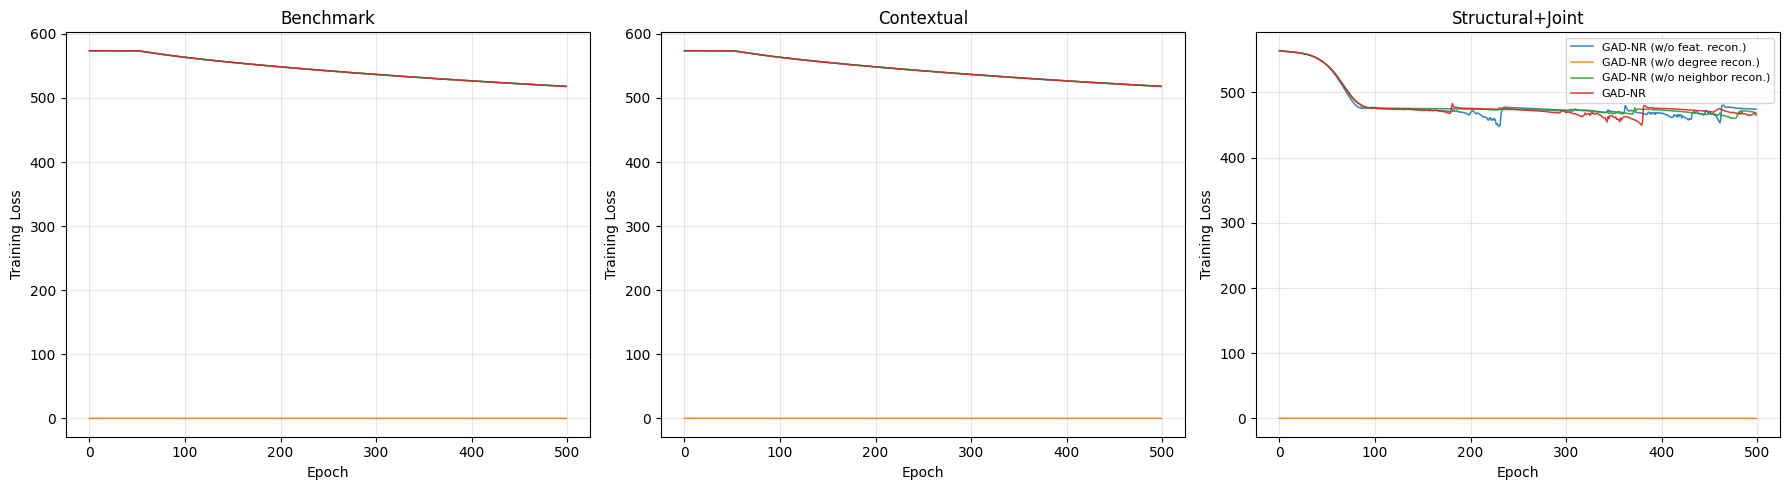


=== Final Paper Comparison Summary ===

--- Benchmark ---
                       Model  Mean AUC  Std AUC  Paper Mean  Paper Std  Delta Mean  Within Paper Std
   GAD-NR (w/o feat. recon.)     80.30      0.0       70.20       1.16       10.10             False
  GAD-NR (w/o degree recon.)     76.92      0.0       72.44       1.33        4.48             False
GAD-NR (w/o neighbor recon.)     77.49      0.0       56.01       3.00       21.48             False
                      GAD-NR     76.92      0.0       80.87       2.95       -3.95             False

--- Contextual ---
                       Model  Mean AUC  Std AUC  Paper Mean  Paper Std  Delta Mean  Within Paper Std
   GAD-NR (w/o feat. recon.)     70.09      0.0       68.27       2.09        1.82              True
  GAD-NR (w/o degree recon.)     69.01      0.0       75.25       3.57       -6.24             False
GAD-NR (w/o neighbor recon.)     71.88      0.0       68.23       3.34        3.65             False
            

In [9]:
# Mean training loss curves by task and variant
fig, axes = plt.subplots(1, len(ACTIVE_TASKS), figsize=(6 * len(ACTIVE_TASKS), 5), sharey=False)
if len(ACTIVE_TASKS) == 1:
    axes = [axes]

for ax, task in zip(axes, ACTIVE_TASKS):
    task_name = task['Task']
    for experiment in EXPERIMENTS:
        model_name = experiment['Model']
        series = [loss_history[(task_name, model_name, seed)] for seed in SEEDS]
        series = [values for values in series if len(values) > 0]
        if not series:
            print(f'Skipping loss curve for {task_name} / {model_name}: no finite loss history.')
            continue
        min_len = min(len(values) for values in series)
        mean_loss = np.mean([values[:min_len] for values in series], axis=0)
        ax.plot(mean_loss, linewidth=1.1, alpha=0.9, label=model_name)
    ax.set_title(task_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.grid(True, alpha=0.3)

axes[-1].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('loss_curve_enron_paper_replication.png', dpi=150)
plt.show()

print('\n=== Final Paper Comparison Summary ===')
for task_name in summary_df['Task'].drop_duplicates():
    print(f'\n--- {task_name} ---')
    cols = ['Model', 'Mean AUC', 'Std AUC', 'Paper Mean', 'Paper Std', 'Delta Mean', 'Within Paper Std']
    print(summary_df.loc[summary_df['Task'] == task_name, cols].to_string(index=False))

print('\nCSVs:')
print('  gadnr_enron_paper_run_level_results.csv')
print('  gadnr_enron_paper_comparison_summary.csv')
print('Plot: loss_curve_enron_paper_replication.png')
